# Mistral 7B Instruct v0.3 — Prompting Techniques for Reasoning

Comparing **zero-shot**, **few-shot**, **few-shot CoT**, and **zero-shot CoT** prompting on the `facebook/natural_reasoning` dataset.

**Model**: `mistralai/Mistral-7B-Instruct-v0.3` (4-bit quantized)

In [4]:
!pip install transformers accelerate bitsandbytes
!pip install rouge-score bert-score tqdm

In [5]:
import json
import re
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from rouge_score import rouge_scorer
from bert_score import score as compute_bert_score
from huggingface_hub import login
from google.colab import drive, userdata, files

In [6]:
login(token=userdata.get("HF_TOKEN"))
print("Logged into HuggingFace")

Logged into HuggingFace


## Configuration

In [7]:
MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.3"
DRIVE_DATA_PATH = "/content/drive/MyDrive/NLP Project/Data"
SEED = 42
ANSWER_MARKER = "ANSWER:"

TECHNIQUES = ["zero_shot", "few_shot", "few_shot_cot", "zero_shot_cot"]

MAX_TOKENS_BY_TYPE = {
    "single_word": 256,
    "short": 512,
    "long": 1024,
    "no_answer": 1024,
}

In [8]:
def get_batch_size(avg_input_tokens):
    if avg_input_tokens < 500:
        return 12
    elif avg_input_tokens < 1000:
        return 8
    elif avg_input_tokens < 1500:
        return 6
    else:
        return 4

## Dataset

In [9]:
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
with open(f'{DRIVE_DATA_PATH}/sampled.jsonl', 'r', encoding='utf-8') as f:
    dataset = [json.loads(line) for line in f]

ref_70b = {}
for item in dataset:
    if item.get('responses'):
        ref_70b[item['sample_id']] = item['responses'][0]['response']

print(f'Loaded {len(dataset)} questions')
print(f'70B reference responses available: {len(ref_70b)}')

Loaded 100 questions
70B reference responses available: 100


In [11]:
df_data = pd.DataFrame(dataset)
print(df_data['answer_type'].value_counts())
print()
df_data[['sample_id', 'answer_type', 'question']].head(10)

answer_type
short          37
long           35
no_answer      18
single_word    10
Name: count, dtype: int64



,sample_id,answer_type,question
0,0,short,Given the information about Company B and Comp...
1,1,no_answer,Prove or disprove that an upper bound for $\rh...
2,2,single_word,A block of mass $m$ is released from a height ...
3,3,long,Discuss the role of dopamine in the developmen...
4,4,long,Construct a voltmeter with max impact/effect a...
5,5,short,"Prove that if a^2 is algebraic over a field F,..."
6,6,long,"Compare and contrast the concepts of Belief, T..."
7,7,short,Given an affine variety $X \subset \mathbb{C}^...
8,8,long,Explain how the property of spin in subatomic ...
9,9,single_word,"Given $x=20062007$, and let $$A=\sqrt{x^2+\sqr..."


## Model

In [12]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map='auto',
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'

print(f'Model loaded: {MODEL_NAME}')
print(f'GPU memory used: {torch.cuda.memory_allocated() / 1e9:.2f} GB')
print(f'GPU memory reserved: {torch.cuda.memory_reserved() / 1e9:.2f} GB')

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/141k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded: mistralai/Mistral-7B-Instruct-v0.3
GPU memory used: 4.50 GB
GPU memory reserved: 4.63 GB


## Prompting Techniques

In [13]:
FEW_SHOT_EXAMPLES = [
    {
        "question": "A projectile is launched at an angle of 30° above the horizontal with an initial speed of 50 m/s. Calculate the maximum height reached by the projectile. Use g = 9.8 m/s².",
        "answer": "The maximum height is approximately 31.9 meters.",
        "reasoning": "The vertical component of the initial velocity is v₀y = 50 × sin(30°) = 50 × 0.5 = 25 m/s. At maximum height, the vertical velocity becomes zero. Using the kinematic equation v² = v₀² - 2gh, we set v = 0: 0 = (25)² - 2(9.8)h, which gives 0 = 625 - 19.6h. Solving: h = 625 / 19.6 ≈ 31.9 m."
    },
    {
        "question": "Prove that the sum of the first n odd numbers equals n².",
        "answer": "By mathematical induction, the sum 1 + 3 + 5 + ... + (2n-1) = n².",
        "reasoning": "We prove by induction. Base case: n=1, the first odd number is 1, and 1² = 1. ✓ Inductive step: Assume 1 + 3 + ... + (2k-1) = k². Adding the next odd number (2k+1): k² + (2k+1) = k² + 2k + 1 = (k+1)². ✓ By induction, the statement holds for all positive integers n."
    },
    {
        "question": "Explain why metals are good conductors of electricity compared to non-metals.",
        "answer": "Metals conduct electricity well because metallic bonding creates delocalized electrons that are free to move throughout the material when a voltage is applied.",
        "reasoning": "In metallic bonding, atoms release their outer valence electrons into a shared 'electron sea' that permeates the crystal lattice. These delocalized electrons are not bound to any particular atom and can move freely. When an electric field is applied, these free electrons drift in the direction of the field, creating an electric current. Non-metals have their electrons tightly bound in covalent bonds or localized orbitals, leaving very few free charge carriers available to conduct electricity."
    }
]

In [14]:
def build_messages(question, technique):
    if technique == "zero_shot":
        return [
            {"role": "user", "content": "You are a knowledgeable assistant. Answer the following question. After your explanation, state your final answer on a new line starting with 'ANSWER:'\n\n" + question}
        ]

    elif technique == "few_shot":
        messages = [
            {"role": "user", "content": "You are a knowledgeable assistant. Answer questions thoroughly. State your final answer on a new line starting with 'ANSWER:'"},
            {"role": "assistant", "content": "Understood. I will answer questions thoroughly and state my final answer starting with 'ANSWER:'."}
        ]
        for ex in FEW_SHOT_EXAMPLES:
            messages.append({"role": "user", "content": ex["question"]})
            messages.append({"role": "assistant", "content": f"ANSWER: {ex['answer']}"})
        messages.append({"role": "user", "content": question})
        return messages

    elif technique == "few_shot_cot":
        messages = [
            {"role": "user", "content": "You are a knowledgeable assistant. Think through problems step by step. State your final answer on a new line starting with 'ANSWER:'"},
            {"role": "assistant", "content": "Understood. I will think through problems step by step and state my final answer starting with 'ANSWER:'."}
        ]
        for ex in FEW_SHOT_EXAMPLES:
            messages.append({"role": "user", "content": ex["question"]})
            messages.append({"role": "assistant", "content": f"{ex['reasoning']}\n\nANSWER: {ex['answer']}"})
        messages.append({"role": "user", "content": question})
        return messages

    elif technique == "zero_shot_cot":
        return [
            {"role": "user", "content": f"{question}\n\nLet's approach this systematically. "
            "Identify what is given, determine what needs to be found, and apply "
            "the relevant principles step by step. After your reasoning, state "
            "your final answer on a new line starting with 'ANSWER:'"}
        ]

## Inference

In [15]:
def generate_batch(messages_list, max_new_tokens=1024):
    templated = [
        tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        for msgs in messages_list
    ]
    inputs = tokenizer(
        templated, return_tensors='pt', padding=True, truncation=True, max_length=2048
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.15,
            pad_token_id=tokenizer.eos_token_id,
        )

    responses = []
    for i, output in enumerate(outputs):
        prompt_len = inputs['input_ids'][i].shape[0]
        decoded = tokenizer.decode(output[prompt_len:], skip_special_tokens=True)
        responses.append(decoded.strip())
    return responses

In [16]:
results = []

for technique in TECHNIQUES:
    torch.cuda.empty_cache()
    print(f"\n{'='*60}")
    print(f'Running: {technique}')
    print(f'GPU memory: {torch.cuda.memory_allocated() / 1e9:.2f} GB')
    print(f"{'='*60}")

    all_messages = [build_messages(item['question'], technique) for item in dataset]
    templated_for_len = [
        tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        for msgs in all_messages
    ]
    input_lengths = [len(tokenizer.encode(t)) for t in templated_for_len]

    sorted_indices = sorted(range(len(dataset)), key=lambda i: input_lengths[i])
    all_messages = [all_messages[i] for i in sorted_indices]
    sorted_items = [dataset[i] for i in sorted_indices]
    sorted_lengths = [input_lengths[i] for i in sorted_indices]

    avg_len = sum(sorted_lengths) / len(sorted_lengths)
    batch_size = get_batch_size(avg_len)
    print(f'Avg input tokens: {avg_len:.0f} -> batch size: {batch_size}')

    for batch_start in tqdm(range(0, len(dataset), batch_size), desc=technique):
        batch_end = min(batch_start + batch_size, len(dataset))
        batch_messages = all_messages[batch_start:batch_end]
        batch_items = sorted_items[batch_start:batch_end]

        batch_max_tokens = max(
            MAX_TOKENS_BY_TYPE.get(item['answer_type'], 1024)
            for item in batch_items
        )

        start = time.time()
        responses = generate_batch(batch_messages, max_new_tokens=batch_max_tokens)
        gen_time = (time.time() - start) / len(responses)

        for item, response in zip(batch_items, responses):
            results.append({
                'sample_id': item['sample_id'],
                'question': item['question'],
                'reference_answer': item['reference_answer'],
                'answer_type': item['answer_type'],
                'technique': technique,
                'response': response,
                'generation_time': gen_time,
                'response_length': len(response.split()),
            })

df = pd.DataFrame(results)
print(f'\nDone: {len(df)} results ({len(dataset)} questions x {len(TECHNIQUES)} techniques)')


Running: zero_shot
GPU memory: 4.50 GB
Avg input tokens: 117 -> batch size: 12


zero_shot:   0%|          | 0/9 [00:00<?, ?it/s]


Running: few_shot
GPU memory: 4.51 GB
Avg input tokens: 306 -> batch size: 12


few_shot:   0%|          | 0/9 [00:00<?, ?it/s]


Running: few_shot_cot
GPU memory: 4.51 GB
Avg input tokens: 667 -> batch size: 8


few_shot_cot:   0%|          | 0/13 [00:00<?, ?it/s]


Running: zero_shot_cot
GPU memory: 4.51 GB
Avg input tokens: 135 -> batch size: 12


zero_shot_cot:   0%|          | 0/9 [00:00<?, ?it/s]


Done: 400 results (100 questions x 4 techniques)


In [17]:
df.to_json("/content/results_mistral.json", orient="records", indent=2)
files.download("/content/results_mistral.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
del model
torch.cuda.empty_cache()
print(f'GPU memory after cleanup: {torch.cuda.memory_allocated() / 1e9:.2f} GB')

GPU memory after cleanup: 3.97 GB


## Answer Extraction & Normalization

In [19]:
def normalize_latex(text):
    text = re.sub(r'\\frac\{([^}]+)\}\{([^}]+)\}', r'\1/\2', text)
    text = re.sub(r'\\boxed\{([^}]+)\}', r'\1', text)
    text = re.sub(r'\$+', '', text)
    text = re.sub(r'\\(left|right|quad|qquad|text|mathrm|mathbf|displaystyle)\b', '', text)
    text = re.sub(r'\\{2,}', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_response(response):
    response = re.sub(r'^#+\s*(Step\s*\d+|Solution|Answer|Explanation)[:\s]*', '', response, flags=re.MULTILINE)
    response = re.sub(r"^(I'd be happy to help!?|Sure!?|Here's? (?:the|my) (?:answer|solution|response)[:\s]*)", '', response, flags=re.IGNORECASE)
    return response.strip()

def extract_answer(response):
    if ANSWER_MARKER in response:
        return response.split(ANSWER_MARKER)[-1].strip()

    boxed = re.findall(r'\\boxed\{([^}]+)\}', response)
    if boxed:
        return boxed[-1]

    patterns = [
        r'(?:the\s+)?(?:final\s+)?answer\s+is[:\s]+(.+?)(?:\.|$)',
        r'therefore[,:\s]+(.+?)(?:\.|$)',
    ]
    for pattern in patterns:
        match = re.search(pattern, response, re.IGNORECASE | re.DOTALL)
        if match:
            return match.group(1).strip()

    sentences = [s.strip() for s in response.rstrip('.').split('.') if s.strip()]
    return sentences[-1] if sentences else response

def normalize(text):
    text = normalize_latex(text)
    return text.lower().strip().rstrip('.')

## Evaluation

In [20]:
rouge_l_scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

def exact_match(prediction, reference):
    return normalize(extract_answer(prediction)) == normalize(reference)

def contains_match(prediction, reference):
    ref_norm = normalize(reference)
    pred_norm = normalize(prediction)
    return ref_norm in pred_norm

def compute_rouge_l(prediction, reference):
    return rouge_l_scorer.score(reference, prediction)['rougeL'].fmeasure

def compute_f1_token(prediction, reference):
    pred_tokens = normalize(extract_answer(prediction)).split()
    ref_tokens = normalize(reference).split()
    if not pred_tokens or not ref_tokens:
        return 0.0
    pred_counts = Counter(pred_tokens)
    ref_counts = Counter(ref_tokens)
    common = sum((pred_counts & ref_counts).values())
    if not common:
        return 0.0
    precision = common / len(pred_tokens)
    recall = common / len(ref_tokens)
    return 2 * precision * recall / (precision + recall)

In [21]:
has_ref = df[df['answer_type'] != 'no_answer'].copy()
has_ref['extracted_answer'] = has_ref['response'].apply(extract_answer)
has_ref['exact_match'] = has_ref.apply(lambda r: exact_match(r['response'], r['reference_answer']), axis=1)
has_ref['contains_match'] = has_ref.apply(lambda r: contains_match(r['response'], r['reference_answer']), axis=1)
has_ref['rouge_l'] = has_ref.apply(lambda r: compute_rouge_l(r['response'], r['reference_answer']), axis=1)
has_ref['rouge_l_extracted'] = has_ref.apply(lambda r: compute_rouge_l(r['extracted_answer'], r['reference_answer']), axis=1)
has_ref['f1_token'] = has_ref.apply(lambda r: compute_f1_token(r['response'], r['reference_answer']), axis=1)
has_ref['has_marker'] = has_ref['response'].str.contains(ANSWER_MARKER, regex=False)
print('ANSWER: marker hit rate by technique:')
print(has_ref.groupby('technique')['has_marker'].mean().round(4))
print()

ANSWER: marker hit rate by technique:
technique
few_shot         0.8659
few_shot_cot     0.9512
zero_shot        0.8293
zero_shot_cot    0.8415
Name: has_marker, dtype: float64



### BERTScore & 70B Reference Comparison

In [22]:
has_ref['ref_70b'] = has_ref['sample_id'].map(ref_70b)
mask_70b = has_ref['ref_70b'].notna()
preds_ref = has_ref['response'].tolist()
refs_ref = has_ref['reference_answer'].tolist()
preds_70b = has_ref[mask_70b]['response'].tolist()
refs_70b_list = has_ref[mask_70b]['ref_70b'].tolist()
all_preds = preds_ref + preds_70b
all_refs = refs_ref + refs_70b_list
print(f'Computing BERTScore for {len(all_preds)} pairs...')
P, R, F1 = compute_bert_score(all_preds, all_refs, lang='en', verbose=True)
n_ref = len(preds_ref)
has_ref['bertscore_f1'] = F1[:n_ref].numpy()
has_ref.loc[mask_70b, 'bertscore_vs_70b'] = F1[n_ref:].numpy()
has_ref.loc[mask_70b, 'rouge_l_vs_70b'] = has_ref[mask_70b].apply(
    lambda r: compute_rouge_l(r['response'], r['ref_70b']), axis=1
)
print('Done!')

Computing BERTScore for 656 pairs...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/8 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/11 [00:00<?, ?it/s]

done in 36.28 seconds, 18.08 sentences/sec
Done!


In [23]:
metrics = has_ref.groupby('technique').agg(
    exact_match=('exact_match', 'mean'),
    contains_match=('contains_match', 'mean'),
    rouge_l=('rouge_l', 'mean'),
    bertscore_f1=('bertscore_f1', 'mean'),
    f1_token=('f1_token', 'mean'),
    rouge_l_vs_70b=('rouge_l_vs_70b', 'mean'),
    bertscore_vs_70b=('bertscore_vs_70b', 'mean'),
    avg_response_len=('response_length', 'mean'),
    avg_gen_time=('generation_time', 'mean'),
).round(4)

metrics

,exact_match,contains_match,rouge_l,bertscore_f1,f1_token,rouge_l_vs_70b,bertscore_vs_70b,avg_response_len,avg_gen_time
technique,,,,,,,,,
few_shot,0.0,0.0488,0.1057,0.8292,0.1083,0.2219,0.8540,191.8415,39.2768
few_shot_cot,0.0,0.0610,0.0906,0.8163,0.2041,0.2491,0.8525,248.0000,52.2572
zero_shot,0.0,0.0610,0.0688,0.8147,0.2092,0.2785,0.8635,367.5488,42.7607
zero_shot_cot,0.0,0.0610,0.0655,0.8097,0.1583,0.2664,0.8579,373.3659,42.9603


## Analysis

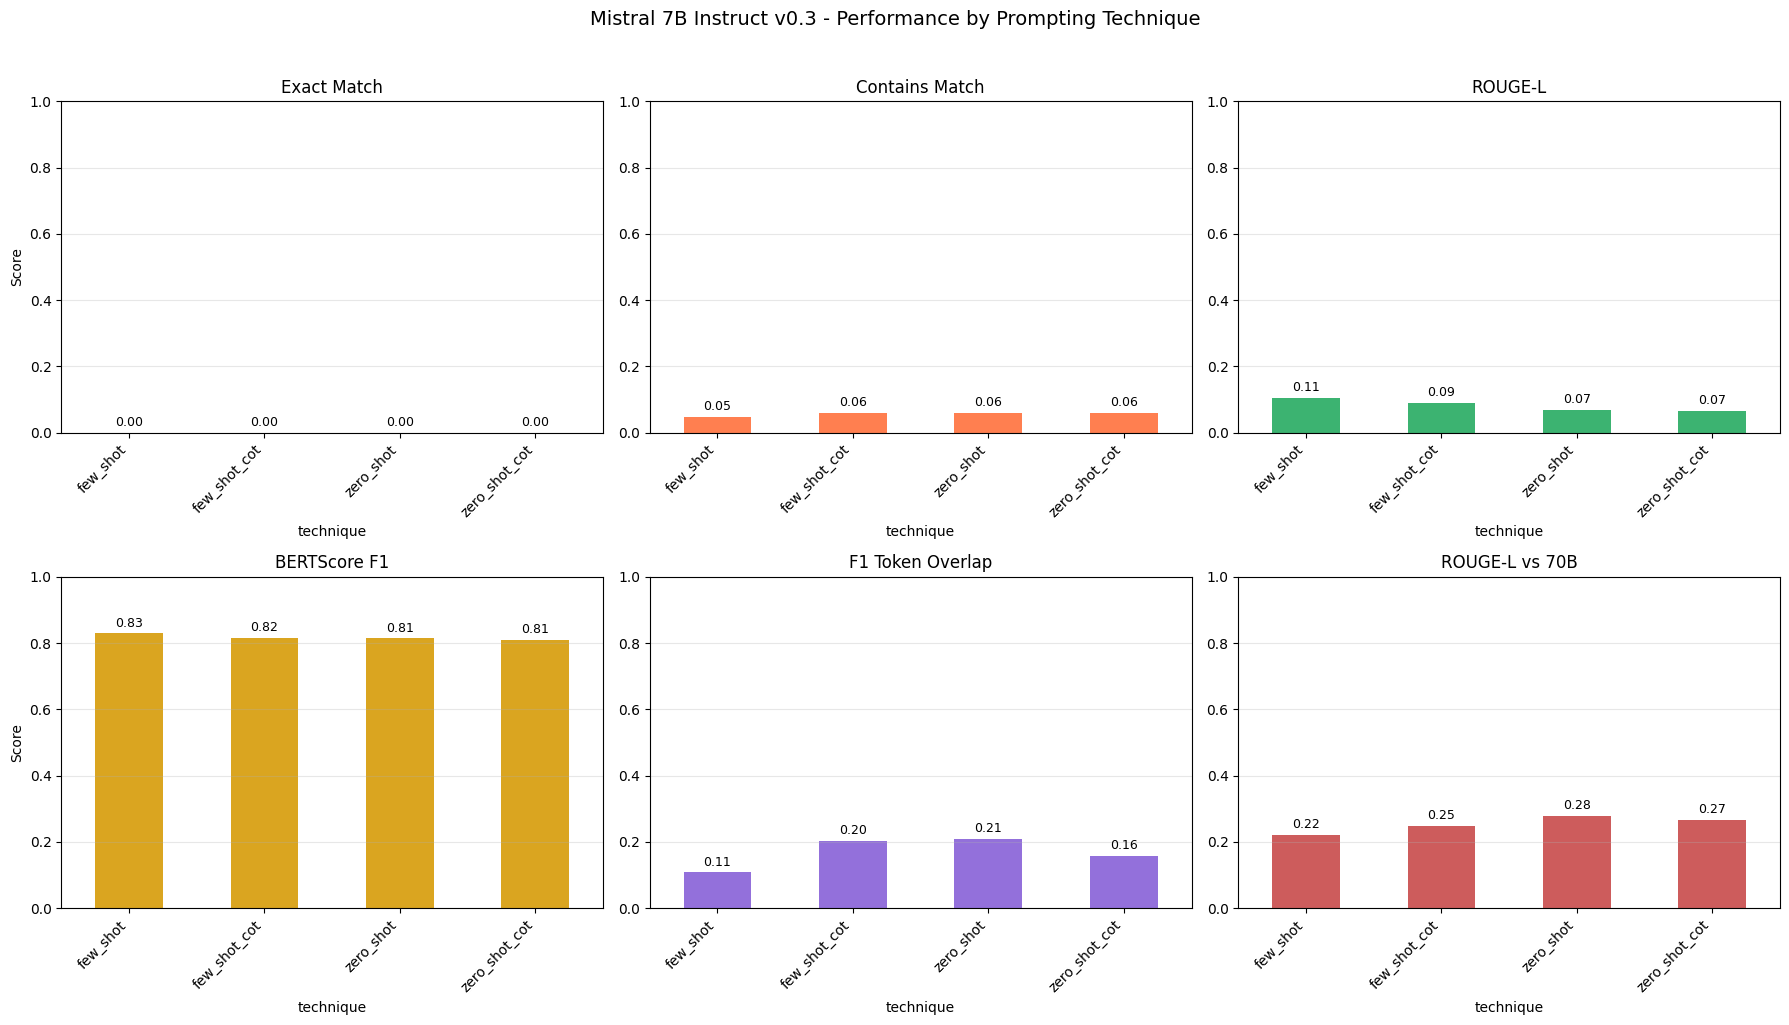

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors = ['steelblue', 'coral', 'mediumseagreen', 'goldenrod', 'mediumpurple', 'indianred']
metric_cols = [
    ('exact_match', 'Exact Match'), ('contains_match', 'Contains Match'),
    ('rouge_l', 'ROUGE-L'), ('bertscore_f1', 'BERTScore F1'),
    ('f1_token', 'F1 Token Overlap'), ('rouge_l_vs_70b', 'ROUGE-L vs 70B'),
]
for idx, (col, title) in enumerate(metric_cols):
    ax = axes[idx // 3][idx % 3]
    metrics[col].plot(kind='bar', ax=ax, color=colors[idx])
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(metrics[col]):
        ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
axes[0][0].set_ylabel('Score')
axes[1][0].set_ylabel('Score')
plt.suptitle('Mistral 7B Instruct v0.3 - Performance by Prompting Technique', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

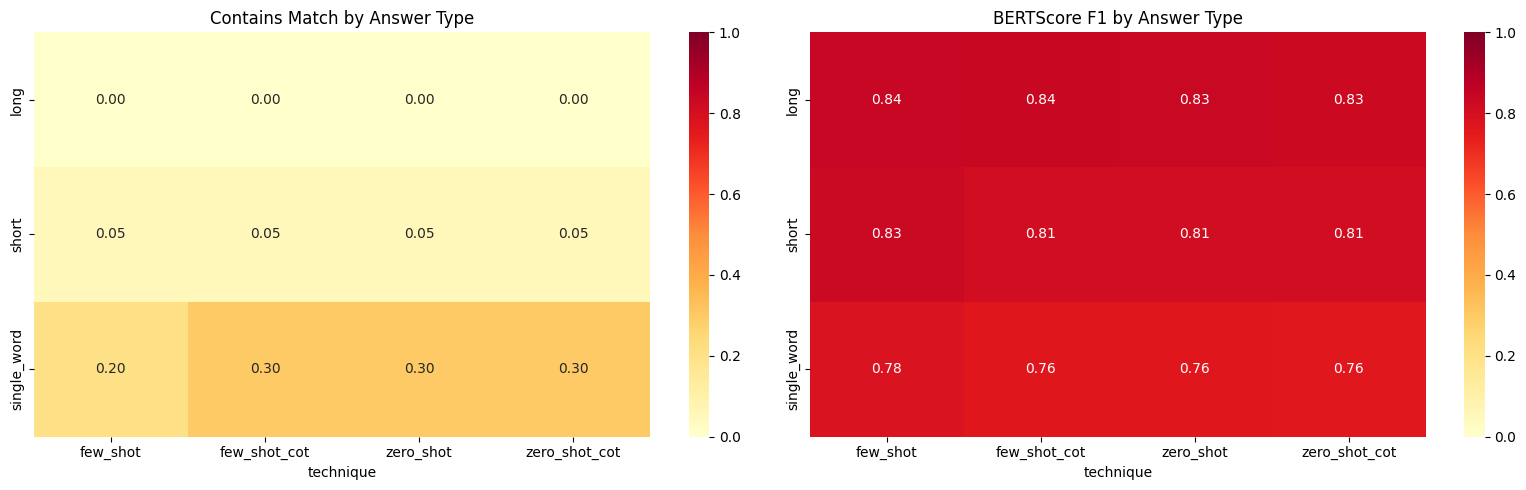

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, metric, title in [
    (axes[0], 'contains_match', 'Contains Match by Answer Type'),
    (axes[1], 'bertscore_f1', 'BERTScore F1 by Answer Type'),
]:
    pivot = has_ref.groupby(['answer_type', 'technique'])[metric].mean().unstack()
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

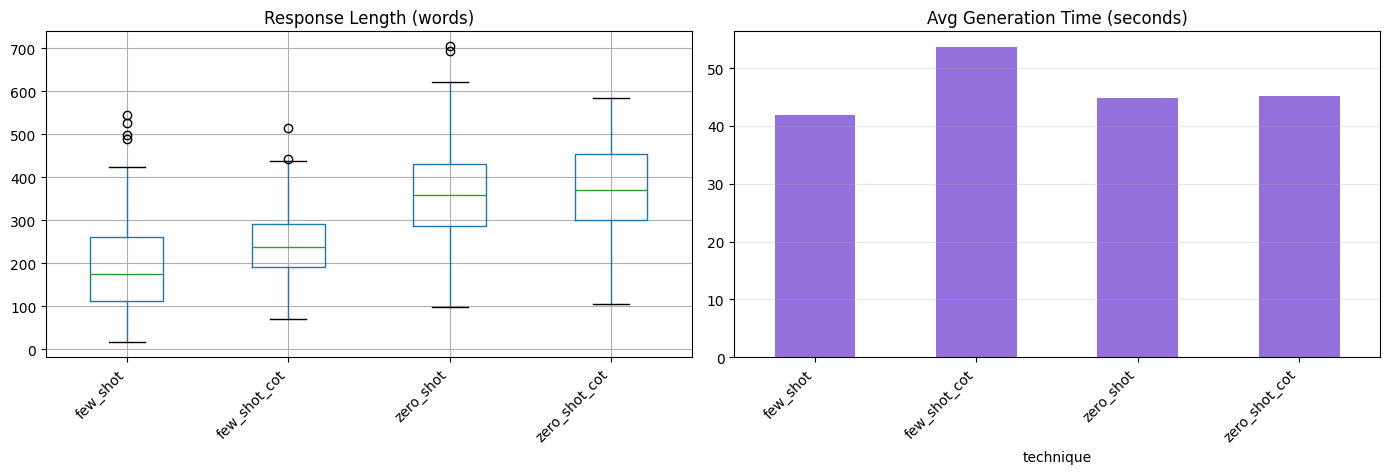

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.boxplot(column='response_length', by='technique', ax=axes[0])
axes[0].set_title('Response Length (words)')
axes[0].set_xlabel('')
plt.sca(axes[0])
plt.xticks(rotation=45, ha='right')
df.groupby('technique')['generation_time'].mean().plot(kind='bar', ax=axes[1], color='mediumpurple')
axes[1].set_title('Avg Generation Time (seconds)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)
plt.suptitle('')
plt.tight_layout()
plt.show()

### Qualitative Comparison

In [27]:
def show_comparison(sample_id):
    subset = df[df['sample_id'] == sample_id]
    row0 = subset.iloc[0]
    print(f"Question: {row0['question'][:300]}")
    ref = row0['reference_answer']
    print(f"Reference: {ref[:200] if ref else '(none)'}")
    print('-' * 80)
    for _, row in subset.iterrows():
        extracted = extract_answer(row['response'])
        print(f"\n[{row['technique']}] ({row['response_length']} words, {row['generation_time']:.1f}s)")
        print(f"Extracted: {extracted[:200]}")
        print(f"Full: {row['response'][:400]}")
    print('\n' + '=' * 80 + '\n')

for atype in ['single_word', 'short', 'long']:
    sid = df[df['answer_type'] == atype]['sample_id'].iloc[0]
    show_comparison(sid)

Question: What is the value of a number 'raised' to a fractional tetration number, specifically what is the value of 3 with a tetration number of 4/3?
Reference: 4.834730793026332...
--------------------------------------------------------------------------------

[zero_shot] (268 words, 47.6s)
Extracted: The value of 3 raised to the power of 4/3 depends on the chosen interpretation. Using the Princeton notation, the result is approximately 3.69444486226925. With other interpretations, such as repeated
Full: Tetration (also known as hyper-exponentiation or iterated exponentiation) is an extension of exponentiation where you repeat the operation multiple times. In this case, we have a base number 3 and a tetration index of 4/3. However, it's important to note that tetration isn't standardized like exponentiation, so there can be different interpretations depending on the context.

One common interpreta

[few_shot] (44 words, 14.7s)
Extracted: Tetration is not a standard mathematical ope

### CoT Impact Analysis

Pairwise comparison: how often does adding chain-of-thought fix or break answers?

In [28]:
comparisons = [
    ('zero_shot', 'zero_shot_cot', 'Zero-Shot vs Zero-Shot CoT'),
    ('few_shot', 'few_shot_cot', 'Few-Shot vs Few-Shot CoT'),
    ('zero_shot_cot', 'few_shot_cot', 'Zero-Shot CoT vs Few-Shot CoT'),
]

for t1, t2, title in comparisons:
    df1 = has_ref[has_ref['technique'] == t1].set_index('sample_id')['contains_match']
    df2 = has_ref[has_ref['technique'] == t2].set_index('sample_id')['contains_match']
    both_right = (df1 & df2).sum()
    only_t1 = (df1 & ~df2).sum()
    only_t2 = (~df1 & df2).sum()
    both_wrong = (~df1 & ~df2).sum()
    print(f'\n{title}')
    print(f'  Both correct:  {both_right}')
    print(f'  Only {t1}: {only_t1}')
    print(f'  Only {t2}: {only_t2}')
    print(f'  Both wrong:    {both_wrong}')


Zero-Shot vs Zero-Shot CoT
  Both correct:  5
  Only zero_shot: 0
  Only zero_shot_cot: 0
  Both wrong:    77

Few-Shot vs Few-Shot CoT
  Both correct:  4
  Only few_shot: 0
  Only few_shot_cot: 1
  Both wrong:    77

Zero-Shot CoT vs Few-Shot CoT
  Both correct:  5
  Only zero_shot_cot: 0
  Only few_shot_cot: 0
  Both wrong:    77


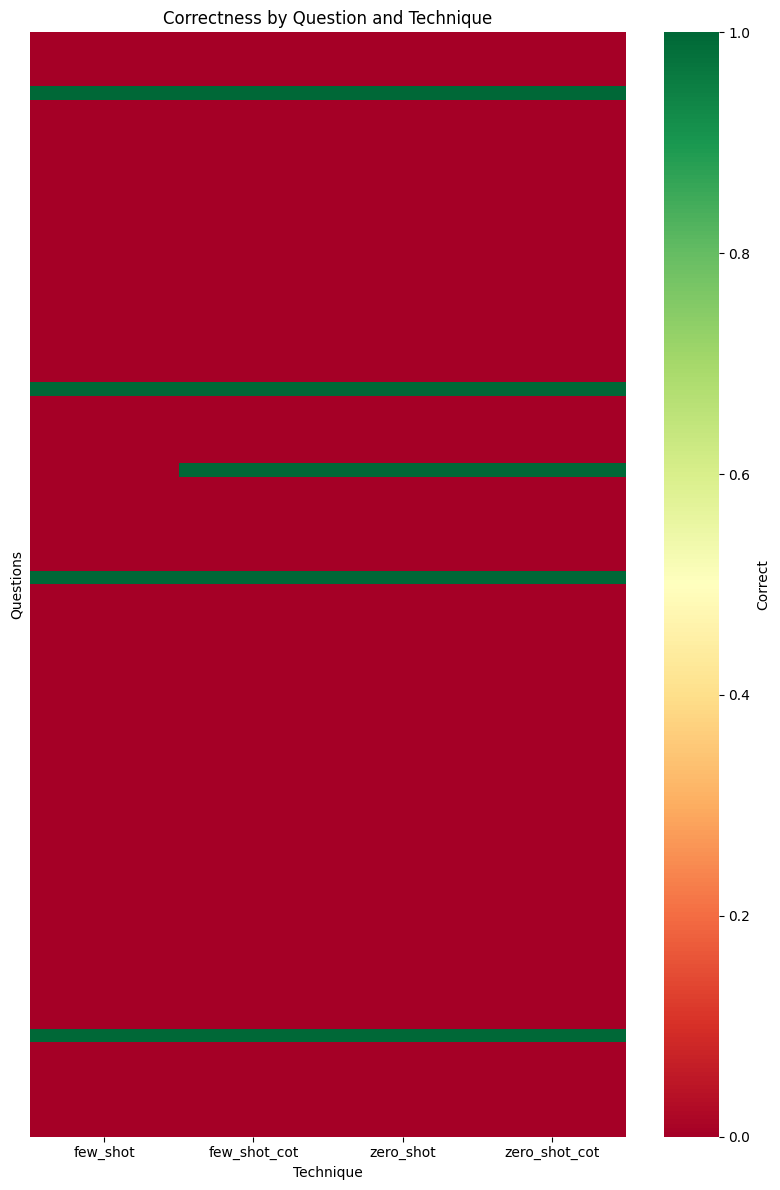

In [29]:
pivot_correct = has_ref.pivot(
    index='sample_id', columns='technique', values='contains_match'
).astype(int)

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(pivot_correct, cmap='RdYlGn', cbar_kws={'label': 'Correct'},
            xticklabels=True, yticklabels=False, ax=ax)
ax.set_title('Correctness by Question and Technique')
ax.set_xlabel('Technique')
ax.set_ylabel('Questions')
plt.tight_layout()
plt.show()